<a href="https://colab.research.google.com/github/dzakirafiffakhriyanto/analisis-numerik-tugas-tugas/blob/main/25083010040_Dzaki_Rafif_Fakhriyanto_Analisis_Numerik_Perahu_Revisi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perhitungan Volume Kedua Lambung Perahu Katamaran

**Nama : Dzaki Rafif Fakhriyanto**

**NPM : 25083010040**

**Kelas : A**

**Link GitHub : https://github.com/dzakirafiffakhriyanto/analisis-luas-dan-volume-perahu-analisis-numerik**

---

## Deskripsi Tugas

Tugas ini menghitung **volume kedua lambung** perahu katamaran fiberglass dari gambar teknik **tampak atas** dan **tampak samping** yang sudah diberi grid ukuran. Gambar perahu bersumber dari penelitian Yuwandana dkk. (2013), *Desain dan Konstruksi Perahu Katamaran Fiberglass untuk Wisata Pancing*, Buletin PSP 21(1), hlm. 119-136.

Sumber gambar: https://www.researchgate.net/publication/342077926_Desain_dan_Konstruksi_Perahu_Katamaran_Fiberglass_untuk_Wisata_Pancing

Nilai lebar dan tinggi lambung dibaca langsung dari gambar secara otomatis, kemudian volume dihitung dengan **dua metode integrasi numerik**, yaitu **metode Trapesium** dan **metode Simpson 1/3**. Seluruh pengerjaan dilakukan dengan pemrograman Python tanpa perhitungan manual.

## Diketahui

- Satu dash dan satu ruang kosong pada grid = 5 + 5 cm = 10 cm.
- Berdasarkan kesepakatan dengan dosen, ukuran **satu kotak grid ditetapkan 45 cm**.
- Lantai kapal dianggap datar (tidak ada keel), sehingga tampak depan setiap penampang berbentuk persegi panjang.
- Volume *reserve buoyancy* tidak dihitung.
- Volume yang dihitung adalah volume **kedua lambung**.

## Konsep Perhitungan

Karena tampak depan setiap penampang berbentuk persegi panjang, luas penampang pada posisi $x$ adalah

$$
A(x) = w(x) \times h(x)
$$

dengan $w(x)$ adalah **lebar** lambung (dibaca dari tampak atas) dan $h(x)$ adalah **tinggi** lambung (dibaca dari tampak samping). Volume satu lambung adalah integral luas penampang sepanjang lambung:

$$
V = \int_{x_0}^{x_N} A(x)\,dx
$$

Karena $A(x)$ hanya diketahui pada titik-titik pengukuran yang berjarak sama sebesar $h_x$, integral dihitung secara numerik.

**Metode Trapesium**

$$
V_T = \frac{h_x}{2}\left[A_0 + 2\sum_{i=1}^{N-1} A_i + A_N\right]
$$

**Metode Simpson 1/3** (jumlah interval $N$ harus genap)

$$
V_S = \frac{h_x}{3}\left[A_0 + 4\sum_{i\ \mathrm{ganjil}} A_i + 2\sum_{i\ \mathrm{genap}} A_i + A_N\right]
$$

## Asumsi dan Keputusan

- Skala mengikuti kesepakatan dengan dosen, yaitu **1 kotak grid = 45 cm**.
- Daerah yang dihitung dibatasi oleh **sekat reserve buoyancy** di kiri dan kanan. Bagian di luar sekat tidak dihitung.
- Lebar lambung diukur pada **tepi luar garis outline**. Tinggi lambung diukur dari **garis sheer** (tepi atas lambung) sampai garis dasar lambung.
- Titik pengukuran diambil pada garis grid vertikal, dengan jumlah interval genap.
- Kedua lambung diukur masing-masing, lalu dibandingkan untuk memastikan keduanya sama.
- Satuan akhir: meter kubik (m³) dan liter.

## Alur Pengerjaan

1. **Fase 1** - Memuat gambar dan menetapkan skala
2. **Fase 2** - Menentukan daerah perhitungan dan titik penampang
3. **Fase 3** - Ekstraksi lebar $w(x)$ dan tinggi $h(x)$ dari gambar
4. **Fase 4** - Luas penampang $A(x)$ dan tabel data
5. **Fase 5** - Integrasi numerik (Trapesium dan Simpson 1/3)
6. **Fase 6** - Uji konvergensi
7. **Fase 7** - Hasil akhir, jawaban soal, dan kesimpulan

## Fase 1: Memuat Gambar dan Menetapkan Skala

Pada fase ini file PDF dibuka, lalu grid dan gambar perahu dipisahkan karena keduanya tersimpan sebagai dua lapisan gambar. Setelah itu garis grid dideteksi untuk mengetahui ukuran satu kotak dalam piksel, dan skala ditetapkan sebesar 1 kotak grid = 45 cm sesuai kesepakatan dengan dosen.

**a) Import library dan memuat file PDF**

In [1]:
%pip install -q pymupdf

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
import pymupdf

plt.rcParams["figure.dpi"] = 110

# Cari file PDF. Jika belum ada di folder kerja, unggah lewat Colab.
NAMA_PDF = "perahu.pdf"
if not os.path.exists(NAMA_PDF):
    from google.colab import files
    unggahan = files.upload()
    NAMA_PDF = list(unggahan.keys())[0]

print("File yang dipakai:", NAMA_PDF)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 28.5 MB/s eta 0:00:00


Saving perahu.pdf to perahu.pdf
File yang dipakai: perahu.pdf


**b) Memisahkan lapisan grid dan lapisan gambar perahu**

In [2]:
def ambil_lapisan_gambar(path_pdf, halaman=0):
    # Ambil semua gambar raster pada halaman PDF beserta mask (alpha) dan posisinya (satuan pt).
    doc = pymupdf.open(path_pdf)
    page = doc[halaman]
    hasil = []
    for info in page.get_images(full=True):
        xref, xref_mask = info[0], info[1]
        rects = page.get_image_rects(xref)
        if not rects:
            continue
        pix = pymupdf.Pixmap(doc, xref)
        if pix.alpha:
            pix = pymupdf.Pixmap(pix, 0)
        rgb = np.frombuffer(pix.samples, np.uint8).reshape(pix.h, pix.w, pix.n)[..., :3].copy()
        mask = None
        if xref_mask:
            pm = pymupdf.Pixmap(doc, xref_mask)
            mask = np.frombuffer(pm.samples, np.uint8).reshape(pm.h, pm.w).copy()
        hasil.append({"rgb": rgb, "mask": mask, "rect": rects[0]})
    return hasil


def hijau(rgb):
    # Piksel berwarna hijau grid
    return (rgb[..., 1] > 100) & (rgb[..., 0] < 80) & (rgb[..., 2] < 80)


lapisan = ambil_lapisan_gambar(NAMA_PDF)
for L in lapisan:
    L["frac_hijau"] = hijau(L["rgb"]).mean()

# Lapisan dengan piksel hijau terbanyak = grid, sisanya = gambar perahu
grid = max(lapisan, key=lambda L: L["frac_hijau"])
perahu = min(lapisan, key=lambda L: L["frac_hijau"])

print("Lapisan grid   : ukuran", grid["rgb"].shape[1], "x", grid["rgb"].shape[0], "piksel")
print("Lapisan perahu : ukuran", perahu["rgb"].shape[1], "x", perahu["rgb"].shape[0], "piksel")

Lapisan grid   : ukuran 2197 x 1770 piksel
Lapisan perahu : ukuran 971 x 687 piksel


**c) Mendeteksi garis grid dan menetapkan skala**

In [3]:
G = grid["rgb"]
hij = hijau(G)
tinggi_g, lebar_g = hij.shape


def kelompok(vektor, ambang, jarak=3):
    # Kelompokkan indeks berurutan yang nilainya melebihi ambang -> daftar (awal, akhir)
    idx = np.where(vektor > ambang)[0]
    hasil = []
    for i in idx:
        if hasil and i - hasil[-1][-1] <= jarak:
            hasil[-1].append(i)
        else:
            hasil.append([i])
    return [(g[0], g[-1]) for g in hasil]


garis_v = kelompok(hij.sum(axis=0), 0.2 * tinggi_g)   # garis grid vertikal (rentang kolom)
garis_h = kelompok(hij.sum(axis=1), 0.2 * lebar_g)    # garis grid horizontal (rentang baris)
pusat_v = np.array([(a + b) / 2 for a, b in garis_v])
pusat_h = np.array([(a + b) / 2 for a, b in garis_h])

# Garis paling luar terpotong tepi gambar, jadi hanya garis bagian dalam yang dipakai untuk jarak kotak
dalam_v, dalam_h = pusat_v[1:-1], pusat_h[1:-1]
kotak_px_x = np.polyfit(np.arange(len(dalam_v)), dalam_v, 1)[0]   # jarak antar garis grid (px), horizontal
kotak_px_y = np.polyfit(np.arange(len(dalam_h)), dalam_h, 1)[0]   # jarak antar garis grid (px), vertikal

# Skala ditetapkan sesuai kesepakatan dengan dosen: 1 kotak grid = 45 cm
CM_PER_KOTAK = 45.0

print(f"Jumlah garis grid terdeteksi : {len(garis_v)} vertikal, {len(garis_h)} horizontal "
      f"({len(garis_v) - 1} x {len(garis_h) - 1} kotak)")
print(f"Jarak antar garis grid       : {kotak_px_x:.2f} px (horizontal), {kotak_px_y:.2f} px (vertikal)")
print(f"1 kotak grid (ketetapan dosen): {CM_PER_KOTAK} cm")

Jumlah garis grid terdeteksi : 21 vertikal, 17 horizontal (20 x 16 kotak)
Jarak antar garis grid       : 106.87 px (horizontal), 106.86 px (vertikal)
1 kotak grid (ketetapan dosen): 45.0 cm


**Penjelasan:** Garis grid dideteksi dari kolom dan baris yang banyak memuat piksel hijau. Hasilnya terdapat 21 garis vertikal dan 17 garis horizontal, sehingga grid terdiri atas 20 × 16 kotak. Jarak antar garis grid adalah sekitar 106,87 piksel (horizontal) dan 106,86 piksel (vertikal). Nilai yang hampir sama pada kedua arah menunjukkan bahwa kotak grid berbentuk bujur sangkar.

Pada soal, satu dash dan satu ruang kosong bernilai 5 + 5 = 10 cm. Berdasarkan kesepakatan dengan dosen, ukuran satu kotak grid ditetapkan sebesar **45 cm** (setara 4,5 pasang dash-celah), dan nilai inilah yang digunakan pada seluruh perhitungan berikutnya.

## Fase 2: Menentukan Daerah Perhitungan dan Titik Penampang

Pada fase ini garis grid dipetakan ke koordinat gambar perahu, lalu posisi **sekat reserve buoyancy** dideteksi secara otomatis untuk menentukan batas kiri dan kanan daerah hitung. Titik-titik penampang (stasiun) diletakkan pada garis grid vertikal di antara kedua sekat.

**a) Menyiapkan gambar perahu dan konversi piksel ke cm**

In [4]:
# "Tinta" = piksel garis gambar perahu (diambil dari mask/alpha), teks kecil dibuang
tinta_mentah = perahu["mask"] > 128
label, n_komp = ndi.label(tinta_mentah, structure=np.ones((3, 3)))
luas_komp = ndi.sum(tinta_mentah, label, range(1, n_komp + 1))
tinta = np.isin(label, 1 + np.where(luas_komp >= 2000)[0])
tinggi_p, lebar_p = tinta.shape

# Posisi dan ukuran tiap lapisan pada halaman PDF (satuan pt)
rg, rp = grid["rect"], perahu["rect"]
pt_per_px_gx = (rg.x1 - rg.x0) / G.shape[1]
pt_per_px_gy = (rg.y1 - rg.y0) / G.shape[0]
pt_per_px_px = (rp.x1 - rp.x0) / lebar_p
pt_per_px_py = (rp.y1 - rp.y0) / tinggi_p

# Posisi garis grid dalam koordinat piksel gambar perahu
gl_x = ((rg.x0 + dalam_v * pt_per_px_gx) - rp.x0) / pt_per_px_px
gl_y = ((rg.y0 + dalam_h * pt_per_px_gy) - rp.y0) / pt_per_px_py
kotak_p_x = np.diff(gl_x).mean()    # piksel gambar perahu per kotak (horizontal)
kotak_p_y = np.diff(gl_y).mean()    # piksel gambar perahu per kotak (vertikal)

# Skala piksel -> cm (sumbu x dan y dihitung terpisah karena gambar perahu sedikit teregang)
CM_PER_PX_X = CM_PER_KOTAK / kotak_p_x
CM_PER_PX_Y = CM_PER_KOTAK / kotak_p_y

print(f"1 kotak grid pada gambar perahu : {kotak_p_x:.2f} px (horizontal), {kotak_p_y:.2f} px (vertikal)")
print(f"Skala sumbu x : {CM_PER_PX_X:.4f} cm/px")
print(f"Skala sumbu y : {CM_PER_PX_Y:.4f} cm/px")

1 kotak grid pada gambar perahu : 45.88 px (horizontal), 46.50 px (vertikal)
Skala sumbu x : 0.9807 cm/px
Skala sumbu y : 0.9678 cm/px


**Penjelasan:** Lapisan grid dan lapisan gambar perahu memiliki resolusi piksel yang berbeda. Oleh karena itu posisi garis grid dikonversi ke koordinat gambar perahu menggunakan posisi dan ukuran masing-masing lapisan pada halaman PDF. Hasilnya, satu kotak grid setara dengan 45,88 piksel (horizontal) dan 46,50 piksel (vertikal) pada gambar perahu. Skala konversi dari piksel ke cm adalah:

$$
s_x = \frac{45}{45{,}88} \approx 0{,}9807\ \text{cm/piksel}, \qquad
s_y = \frac{45}{46{,}50} \approx 0{,}9678\ \text{cm/piksel}
$$

Kedua skala sedikit berbeda karena gambar perahu pada PDF teregang secara horizontal sekitar 1,3% dibandingkan grid. Karena itu skala dihitung terpisah untuk setiap sumbu.

**b) Menentukan jendela tampak atas dan tampak samping**

In [5]:
# Cari kelompok baris yang berisi garis pada kolom tengah (bebas dari palang dan penyangga)
proyeksi = tinta[:, 260:630].sum(axis=1)
baris = np.where(proyeksi > 0)[0]
klaster = []
for r in baris:
    if klaster and r - klaster[-1][-1] <= 25:
        klaster[-1].append(r)
    else:
        klaster.append([r])
klaster = [(int(k[0]), int(k[-1])) for k in klaster]
assert len(klaster) == 6, f"Struktur gambar tidak sesuai dugaan: {klaster}"

JENDELA_L1 = (klaster[0][0], klaster[1][1])     # lambung 1 (atas) pada tampak atas
JENDELA_L2 = (klaster[2][0], klaster[3][1])     # lambung 2 (bawah) pada tampak atas
JENDELA_SAMPING = (klaster[4][0], klaster[5][1])  # tampak samping

print("Baris lambung 1 (tampak atas)  :", JENDELA_L1)
print("Baris lambung 2 (tampak atas)  :", JENDELA_L2)
print("Baris tampak samping           :", JENDELA_SAMPING)

Baris lambung 1 (tampak atas)  : (16, 117)
Baris lambung 2 (tampak atas)  : (352, 453)
Baris tampak samping           : (480, 686)


**Penjelasan:** Gambar perahu dibagi menjadi tiga daerah pembacaan berdasarkan baris piksel yang berisi garis, yaitu lambung 1 pada tampak atas (baris 16 sampai 117), lambung 2 pada tampak atas (baris 352 sampai 453), dan tampak samping (baris 480 sampai 686). Ketiga rentang ini digunakan sebagai jendela pencarian sehingga pembacaan tepi lambung pada fase berikutnya hanya dilakukan pada bagian gambar yang tepat.

**c) Mendeteksi sekat reserve buoyancy dan menentukan titik penampang**

In [6]:
def tepi_lambung(tinta, y_awal, y_akhir, pad=14):
    # Tepi pertama dan terakhir (outline luar) lambung pada tiap kolom
    ys0, ys1 = max(0, y_awal - pad), min(tinta.shape[0] - 1, y_akhir + pad)
    sub = tinta[ys0:ys1 + 1]
    ada = sub.any(axis=0)
    pertama = np.where(ada, sub.argmax(axis=0), np.nan) + ys0
    terakhir = np.where(ada, sub.shape[0] - 1 - sub[::-1].argmax(axis=0), np.nan) + ys0
    return pertama, terakhir


def bersihkan_tepi(e, jendela=81, toleransi=2.5):
    # Buang titik yang menyimpang (terganggu palang/penyangga) lalu isi dengan interpolasi
    e = e.copy()
    x = np.arange(len(e))
    for _ in range(3):
        ok = ~np.isnan(e)
        med = ndi.median_filter(np.where(ok, e, np.nanmedian(e)), size=jendela, mode="nearest")
        e[(~ok) | (np.abs(e - med) > toleransi)] = np.nan
    bagus = ~np.isnan(e)
    return np.interp(x, x[bagus], e[bagus]), ~bagus


def cari_sekat(tinta, atas, bawah, sisi_luar):
    # Sekat = garis di DALAM lambung yang tidak menembus keluar outline (beda dengan palang penghubung)
    kolom = []
    for c in range(40, tinta.shape[1] - 40):
        f, l = int(round(atas[c])), int(round(bawah[c]))
        dalam = tinta[f + 13:l - 12, c]
        if dalam.size < 35:
            continue
        if sisi_luar == "atas":
            menembus = tinta[:max(f - 3, 0), c].any()
        else:
            menembus = tinta[min(l + 4, tinta.shape[0]):, c][:20].any()
        if dalam.mean() > 0.6 and not menembus:
            kolom.append(c)
    kel = []
    for c in kolom:
        if kel and c - kel[-1][-1] <= 3:
            kel[-1].append(c)
        else:
            kel.append([c])
    return [float(np.mean(k)) for k in kel]


# Tepi lambung 1 dan lambung 2 pada tampak atas (sudah dibersihkan dari gangguan)
f1, l1 = tepi_lambung(tinta, *JENDELA_L1)
f2, l2 = tepi_lambung(tinta, *JENDELA_L2)
atas1, bad_a1 = bersihkan_tepi(f1)
bawah1, bad_b1 = bersihkan_tepi(l1)
atas2, bad_a2 = bersihkan_tepi(f2)
bawah2, bad_b2 = bersihkan_tepi(l2)

sekat_1 = cari_sekat(tinta, atas1, bawah1, "atas")
sekat_2 = cari_sekat(tinta, atas2, bawah2, "bawah")
print("Posisi sekat terdeteksi lambung 1 (px):", [round(s, 1) for s in sekat_1])
print("Posisi sekat terdeteksi lambung 2 (px):", [round(s, 1) for s in sekat_2])

# Sekat kiri dan kanan = deteksi paling kiri dan paling kanan pada lambung 1, dicocokkan ke garis grid terdekat
sekat_kiri, sekat_kanan = min(sekat_1), max(sekat_1)
idx_kiri = int(np.argmin(np.abs(gl_x - sekat_kiri)))
idx_kanan = int(np.argmin(np.abs(gl_x - sekat_kanan)))
for nama, s, i in [("kiri", sekat_kiri, idx_kiri), ("kanan", sekat_kanan, idx_kanan)]:
    selisih = abs(gl_x[i] - s) / kotak_p_x
    assert selisih < 0.25, f"Sekat {nama} tidak berimpit dengan garis grid (selisih {selisih:.2f} kotak)"
    print(f"Sekat {nama}: terdeteksi di {s:.1f} px, garis grid terdekat {gl_x[i]:.1f} px (selisih {selisih:.3f} kotak)")

# Titik penampang = garis grid vertikal dari sekat kiri sampai sekat kanan
stasiun_px = gl_x[idx_kiri:idx_kanan + 1]
N = len(stasiun_px) - 1
assert N % 2 == 0, "Jumlah interval harus genap untuk Simpson 1/3"

x_cm = np.arange(N + 1) * CM_PER_KOTAK
print(f"\nJumlah interval N = {N}, jumlah titik = {N + 1}")
print(f"Jarak antar titik h = {CM_PER_KOTAK} cm = {CM_PER_KOTAK / 100:.3f} m")
print(f"Panjang daerah hitung = {x_cm[-1]:.1f} cm = {x_cm[-1] / 100:.3f} m")

Posisi sekat terdeteksi lambung 1 (px): [109.5, 848.0]
Posisi sekat terdeteksi lambung 2 (px): [109.5, 848.0]
Sekat kiri: terdeteksi di 109.5 px, garis grid terdekat 111.7 px (selisih 0.049 kotak)
Sekat kanan: terdeteksi di 848.0 px, garis grid terdekat 845.8 px (selisih 0.048 kotak)

Jumlah interval N = 16, jumlah titik = 17
Jarak antar titik h = 45.0 cm = 0.450 m
Panjang daerah hitung = 720.0 cm = 7.200 m


**Penjelasan:** Sekat *reserve buoyancy* dideteksi secara otomatis sebagai garis di dalam lambung yang tidak menembus keluar outline, sehingga berbeda dengan palang penghubung antar lambung. Pada kedua lambung sekat terdeteksi pada posisi yang sama, yaitu 109,5 piksel (kiri) dan 848,0 piksel (kanan). Posisi tersebut berimpit dengan garis grid terdekat, dengan selisih hanya 0,049 kotak (kiri) dan 0,048 kotak (kanan), jauh di bawah toleransi 0,25 kotak. Dengan demikian batas daerah hitung dapat ditempatkan tepat pada garis grid.

Titik penampang diambil pada setiap garis grid vertikal di antara kedua sekat, sehingga diperoleh $N = 16$ interval dan 17 titik ($x_0, x_1, \ldots, x_{16}$) dengan jarak antar titik $h = 45\ \text{cm} = 0{,}45\ \text{m}$:

$$
x_i = i \cdot h, \qquad L = N \cdot h = 16 \times 0{,}45 = 7{,}2\ \text{m}
$$

Jumlah interval $N = 16$ bernilai genap, sehingga syarat penggunaan metode Simpson 1/3 terpenuhi.

**d) Visualisasi daerah perhitungan dan titik penampang**

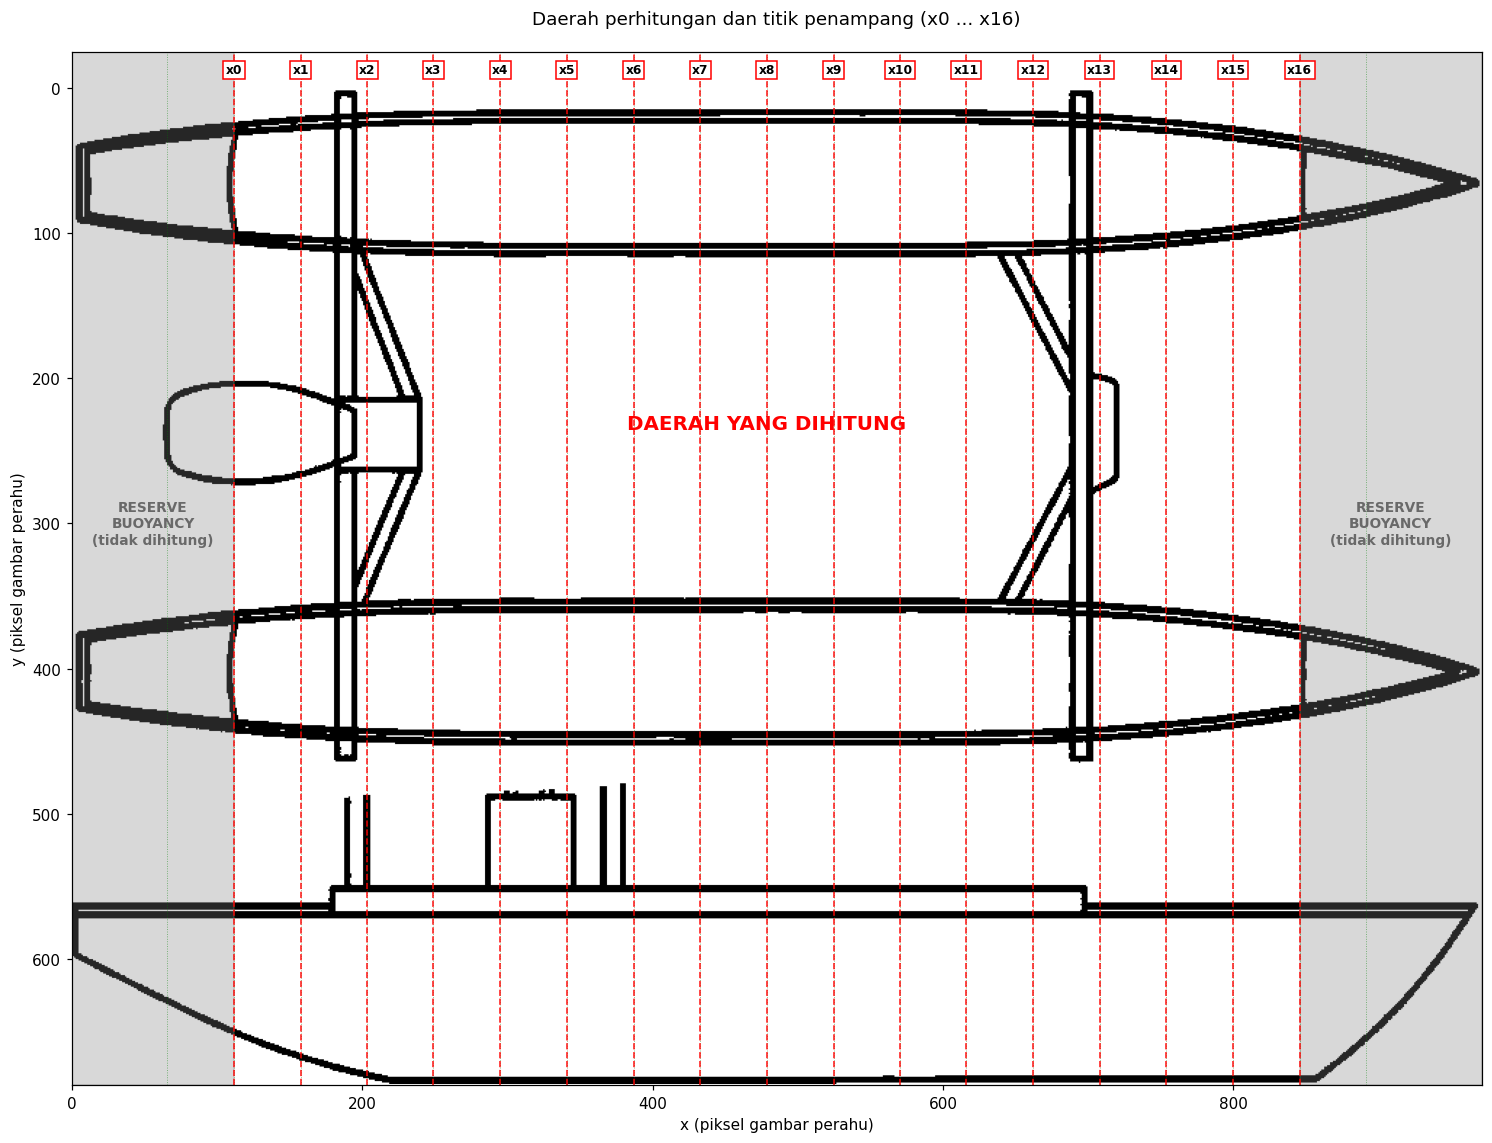

In [7]:
fig, ax = plt.subplots(figsize=(15, 10.5))
ax.imshow(1 - tinta.astype(float), cmap="gray", vmin=0, vmax=1)

# Garis grid (tipis) dan titik penampang (merah)
for gx in gl_x:
    ax.axvline(gx, color="green", lw=0.6, ls=":", alpha=0.5)
for i, sx in enumerate(stasiun_px):
    ax.axvline(sx, color="red", lw=1.1, ls="--", alpha=0.85)
    ax.text(sx, -8, f"x{i}", ha="center", va="bottom", fontsize=8, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="red", pad=1.5))

# Daerah reserve buoyancy (tidak dihitung)
ax.axvspan(0, stasiun_px[0], color="gray", alpha=0.30)
ax.axvspan(stasiun_px[-1], lebar_p, color="gray", alpha=0.30)
for xt in [stasiun_px[0] / 2, (stasiun_px[-1] + lebar_p) / 2]:
    ax.text(xt, 300, "RESERVE\nBUOYANCY\n(tidak dihitung)", ha="center", va="center",
            fontsize=9, fontweight="bold", color="dimgray")

ax.text((stasiun_px[0] + stasiun_px[-1]) / 2, 235, "DAERAH YANG DIHITUNG", ha="center",
        fontsize=13, fontweight="bold", color="red")
ax.set_xlim(0, lebar_p)
ax.set_ylim(tinggi_p, -25)
ax.set_title("Daerah perhitungan dan titik penampang (x0 ... x" + str(N) + ")", pad=18)
ax.set_xlabel("x (piksel gambar perahu)")
ax.set_ylabel("y (piksel gambar perahu)")
plt.tight_layout()
plt.show()

**Penjelasan:** Garis merah putus-putus menandai 17 titik penampang ($x_0$ sampai $x_{16}$) yang berjarak sama. Daerah berwarna abu-abu di kiri dan kanan adalah *reserve buoyancy* yang tidak dihitung sesuai ketentuan soal. Posisi titik penampang yang sama digunakan untuk tampak atas (membaca lebar) dan tampak samping (membaca tinggi), karena kedua tampak sejajar pada sumbu panjang kapal.

## Fase 3: Ekstraksi Lebar $w(x)$ dan Tinggi $h(x)$ dari Gambar

Pada fase ini lebar lambung dibaca dari tampak atas (jarak antara tepi atas dan tepi bawah outline) dan tinggi lambung dibaca dari tampak samping (jarak antara garis sheer dan garis dasar lambung) pada setiap titik penampang. Hasil pembacaan dalam piksel dikonversi ke cm memakai skala dari Fase 2.

**a) Tampak samping: garis sheer dan garis dasar lambung**

In [8]:
# Garis sheer = baris pertama pada tampak samping yang memiliki garis lurus sangat panjang (>= 800 px)
y_s0, y_s1 = JENDELA_SAMPING
panjang_run = []
for r in range(y_s0, y_s1 + 1):
    d = np.diff(np.r_[0, tinta[r].astype(int), 0])
    mulai, selesai = np.where(d == 1)[0], np.where(d == -1)[0]
    panjang_run.append((selesai - mulai).max() if len(mulai) else 0)
panjang_run = np.array(panjang_run)
Y_SHEER = int(y_s0 + np.where(panjang_run >= 800)[0][0])

# Garis dasar lambung = piksel garis paling bawah pada tiap kolom tampak samping
sub_s = tinta[y_s0:y_s1 + 1]
ada_s = sub_s.any(axis=0)
dasar = np.where(ada_s, sub_s.shape[0] - 1 - sub_s[::-1].argmax(axis=0), np.nan) + y_s0
dasar = np.interp(np.arange(lebar_p), np.where(ada_s)[0], dasar[ada_s])

print("Baris garis sheer (tepi atas lambung) :", Y_SHEER, "px")
print("Rentang kolom tampak samping          :", int(np.where(ada_s)[0][0]), "-", int(np.where(ada_s)[0][-1]), "px")

Baris garis sheer (tepi atas lambung) : 568 px
Rentang kolom tampak samping          : 0 - 968 px


**Penjelasan:** Pada tampak samping, garis *sheer* (tepi atas lambung) dikenali sebagai baris pertama yang memuat garis lurus sangat panjang (minimal 800 piksel), sedangkan garis dasar lambung diambil dari piksel garis paling bawah pada setiap kolom. Bagian yang berada di atas garis sheer (dek, kursi, dan atap) bukan bagian lambung sehingga tidak ikut diukur. Tinggi lambung pada suatu titik adalah jarak vertikal antara garis sheer dan garis dasar.

**b) Membaca lebar dan tinggi pada setiap titik penampang**

In [9]:
kolom = np.arange(lebar_p)

# Lebar lambung (cm) = jarak tepi luar atas ke tepi luar bawah, dibaca pada kolom titik penampang
w1_cm = (np.interp(stasiun_px, kolom, bawah1) - np.interp(stasiun_px, kolom, atas1) + 1) * CM_PER_PX_Y
w2_cm = (np.interp(stasiun_px, kolom, bawah2) - np.interp(stasiun_px, kolom, atas2) + 1) * CM_PER_PX_Y

# Tinggi lambung (cm) = jarak garis sheer ke garis dasar, dibaca pada kolom titik penampang yang sama
h_cm = (np.interp(stasiun_px, kolom, dasar) - Y_SHEER + 1) * CM_PER_PX_Y

pembacaan = pd.DataFrame({
    "Titik": [f"x{i}" for i in range(N + 1)],
    "x (cm)": x_cm,
    "Lebar L1 (cm)": w1_cm,
    "Lebar L2 (cm)": w2_cm,
    "Tinggi (cm)": h_cm,
}).round(2)
pembacaan

,Titik,x (cm),Lebar L1 (cm),Lebar L2 (cm),Tinggi (cm)
0,x0,0.0,81.29,81.29,82.96
1,x1,45.0,89.03,89.03,99.68
2,x2,90.0,95.89,95.49,111.29
3,x3,135.0,96.78,97.74,115.16
4,x4,180.0,98.71,98.71,115.16
5,x5,225.0,97.74,97.74,115.16
6,x6,270.0,98.71,98.71,115.16
7,x7,315.0,98.71,98.71,115.16
8,x8,360.0,98.71,98.71,115.16
9,x9,405.0,98.71,98.71,115.16


**Penjelasan:** Lebar dan tinggi lambung pada titik penampang $x_i$ dibaca dengan rumus:

$$
w(x_i) = \big(y_{\text{bawah}}(x_i) - y_{\text{atas}}(x_i) + 1\big) \times s_y
$$

$$
h(x_i) = \big(y_{\text{dasar}}(x_i) - y_{\text{sheer}} + 1\big) \times s_y
$$

Suku $+1$ ditambahkan karena kedua piksel tepi ikut terhitung. Kedua rumus memakai skala sumbu $y$ karena lebar dan tinggi sama-sama diukur searah sumbu vertikal gambar.

Hasilnya, lebar lambung bervariasi dari 62,90 cm (ujung kanan, $x_{16}$) sampai 98,71 cm (bagian tengah), dan lebar lambung 1 hampir sama dengan lambung 2. Tinggi lambung tidak konstan, yaitu 82,96 cm pada $x_0$, naik menjadi 115,16 cm mulai $x_3$, karena dasar lambung melengkung naik ke arah ujung kiri. Pada bagian tengah, dasar lambung datar sesuai asumsi soal. Selisih tinggi 115,16 cm dengan 114,20 cm (sekitar 1,0 cm) setara 1 piksel, sehingga berada pada batas ketelitian pembacaan gambar.

**c) Visualisasi hasil pembacaan pada gambar asli**

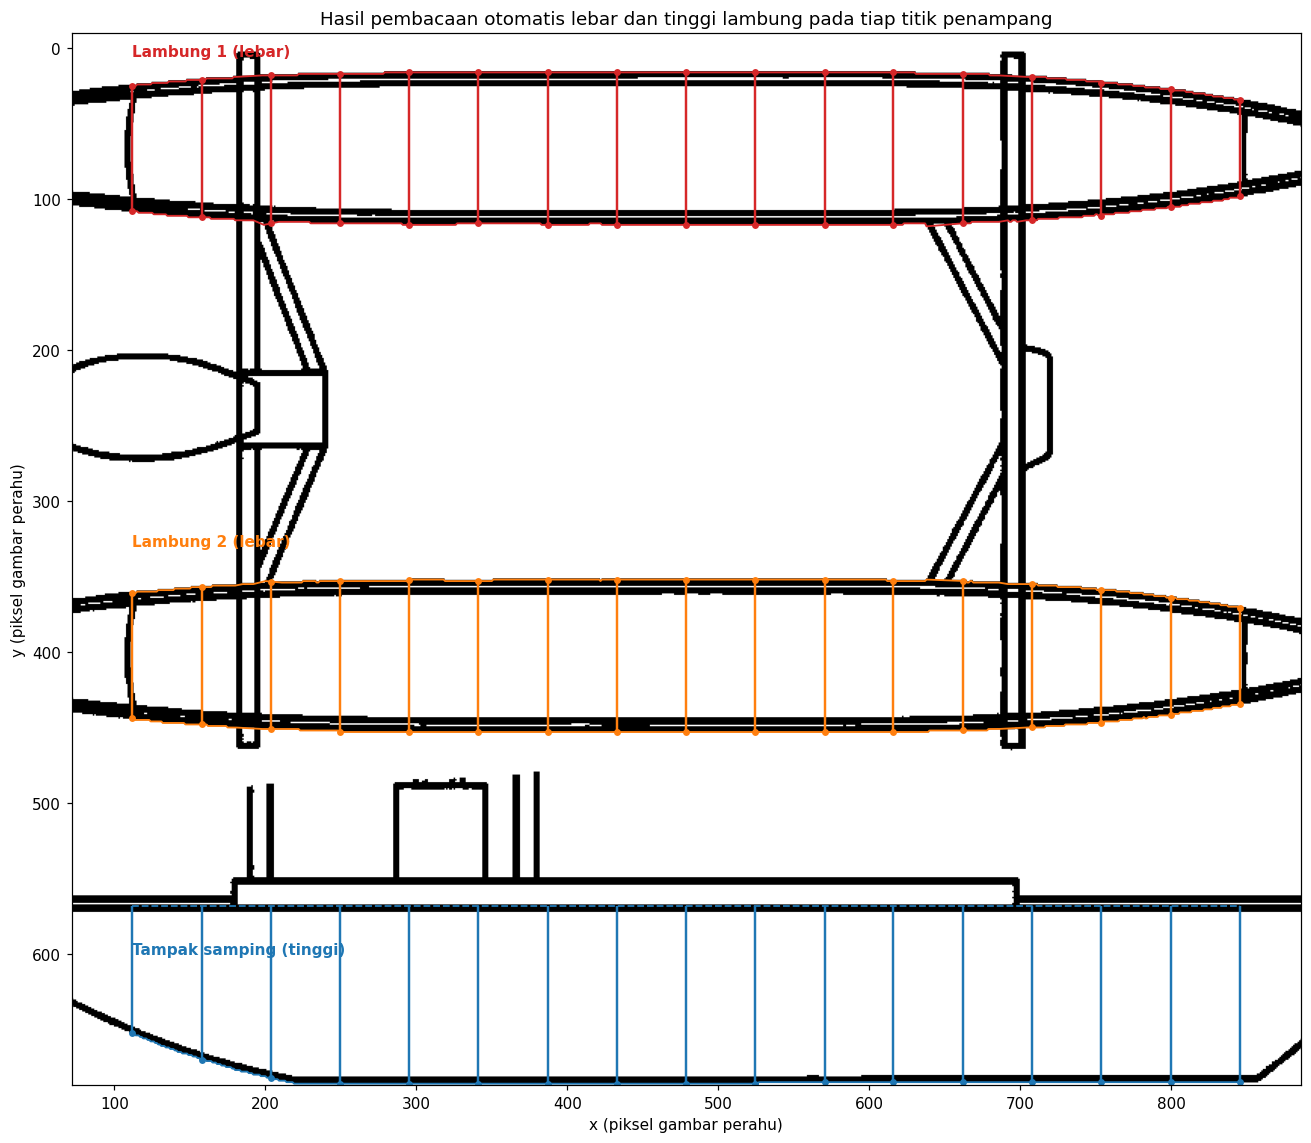

Kolom tepi yang diinterpolasi karena terganggu palang/penyangga (di dalam daerah hitung):
  lambung 1 : tepi atas 33 kolom, tepi bawah 52 kolom
  lambung 2 : tepi atas 55 kolom, tepi bawah 33 kolom


In [10]:
fig, ax = plt.subplots(figsize=(15, 10.5))
ax.imshow(1 - tinta.astype(float), cmap="gray", vmin=0, vmax=1)
xs = np.arange(int(stasiun_px[0]), int(stasiun_px[-1]) + 1)

# Tampak atas: kurva tepi lambung dan segmen lebar pada tiap titik
for atas, bawah, warna in [(atas1, bawah1, "tab:red"), (atas2, bawah2, "tab:orange")]:
    ax.plot(xs, atas[xs], color=warna, lw=1.2)
    ax.plot(xs, bawah[xs], color=warna, lw=1.2)
    ya = np.interp(stasiun_px, kolom, atas)
    yb = np.interp(stasiun_px, kolom, bawah)
    ax.vlines(stasiun_px, ya, yb, color=warna, lw=1.6)
    ax.plot(stasiun_px, ya, "o", color=warna, ms=3.5)
    ax.plot(stasiun_px, yb, "o", color=warna, ms=3.5)

# Tampak samping: garis sheer, garis dasar, dan segmen tinggi pada tiap titik
ax.hlines(Y_SHEER, stasiun_px[0], stasiun_px[-1], color="tab:blue", lw=1.2, ls="--")
ax.plot(xs, dasar[xs], color="tab:blue", lw=1.2)
yd = np.interp(stasiun_px, kolom, dasar)
ax.vlines(stasiun_px, Y_SHEER, yd, color="tab:blue", lw=1.6)
ax.plot(stasiun_px, yd, "o", color="tab:blue", ms=3.5)

ax.text(stasiun_px[0], 5, "Lambung 1 (lebar)", color="tab:red", fontsize=10, fontweight="bold")
ax.text(stasiun_px[0], 330, "Lambung 2 (lebar)", color="tab:orange", fontsize=10, fontweight="bold")
ax.text(stasiun_px[0], 600, "Tampak samping (tinggi)", color="tab:blue", fontsize=10, fontweight="bold")
ax.set_xlim(stasiun_px[0] - 40, stasiun_px[-1] + 40)
ax.set_ylim(tinggi_p, -10)
ax.set_title("Hasil pembacaan otomatis lebar dan tinggi lambung pada tiap titik penampang")
ax.set_xlabel("x (piksel gambar perahu)")
ax.set_ylabel("y (piksel gambar perahu)")
plt.tight_layout()
plt.show()

print("Kolom tepi yang diinterpolasi karena terganggu palang/penyangga (di dalam daerah hitung):")
rng = slice(int(stasiun_px[0]), int(stasiun_px[-1]) + 1)
print("  lambung 1 : tepi atas", int(bad_a1[rng].sum()), "kolom, tepi bawah", int(bad_b1[rng].sum()), "kolom")
print("  lambung 2 : tepi atas", int(bad_a2[rng].sum()), "kolom, tepi bawah", int(bad_b2[rng].sum()), "kolom")

**Penjelasan:** Gambar ini memperlihatkan hasil pembacaan otomatis di atas gambar asli. Kurva merah (lambung 1) dan oranye (lambung 2) mengikuti tepi luar outline lambung, dan garis vertikal pada setiap titik penampang menunjukkan lebar yang terbaca. Pada tampak samping, garis biru putus-putus adalah garis sheer, kurva biru adalah garis dasar, dan garis vertikal biru menunjukkan tinggi lambung. Titik-titik pembacaan jatuh tepat pada garis outline, sehingga pembacaan otomatis dinilai sesuai dengan gambar. Kolom yang terhalang palang atau penyangga diisi dengan interpolasi dari kolom di sekitarnya.

## Fase 4: Luas Penampang $A(x)$ dan Tabel Data

Pada fase ini lebar dan tinggi dikonversi ke meter, kemudian luas penampang pada setiap titik dihitung dengan rumus $A(x) = w(x) \times h(x)$ untuk masing-masing lambung. Hasilnya disusun dalam tabel yang menjadi data masukan untuk integrasi numerik pada fase berikutnya.

**a) Menghitung luas penampang dan menyusun tabel**

In [11]:
# Konversi ke meter
x = x_cm / 100
w1, w2, h = w1_cm / 100, w2_cm / 100, h_cm / 100
h_langkah = CM_PER_KOTAK / 100          # jarak antar titik penampang (m)

# Luas penampang (m^2): penampang tampak depan berbentuk persegi panjang
A1 = w1 * h
A2 = w2 * h

data = pd.DataFrame({
    "Titik": [f"x{i}" for i in range(N + 1)],
    "x (m)": x,
    "Lebar L1 (m)": w1,
    "Lebar L2 (m)": w2,
    "Tinggi (m)": h,
    "A L1 (m²)": A1,
    "A L2 (m²)": A2,
})
data.round(4)

,Titik,x (m),Lebar L1 (m),Lebar L2 (m),Tinggi (m),A L1 (m²),A L2 (m²)
0,x0,0.00,0.8129,0.8129,0.8296,0.6744,0.6744
1,x1,0.45,0.8903,0.8903,0.9968,0.8875,0.8875
2,x2,0.90,0.9589,0.9549,1.1129,1.0672,1.0628
3,x3,1.35,0.9678,0.9774,1.1516,1.1145,1.1257
4,x4,1.80,0.9871,0.9871,1.1516,1.1368,1.1368
5,x5,2.25,0.9774,0.9774,1.1516,1.1257,1.1257
6,x6,2.70,0.9871,0.9871,1.1516,1.1368,1.1368
7,x7,3.15,0.9871,0.9871,1.1516,1.1368,1.1368
8,x8,3.60,0.9871,0.9871,1.1516,1.1368,1.1368
9,x9,4.05,0.9871,0.9871,1.1516,1.1368,1.1368


**Penjelasan:** Lebar dan tinggi dikonversi dari cm ke meter (dibagi 100). Karena tampak depan penampang berbentuk persegi panjang, luas penampang pada setiap titik dihitung dengan:

$$
A_i = w_i \times h_i
$$

Sebagai contoh, pada $x_0$ diperoleh $A = 0{,}8129 \times 0{,}8296 = 0{,}6744\ \text{m}^2$, dan pada $x_4$ diperoleh $A = 0{,}9871 \times 1{,}1516 = 1{,}1368\ \text{m}^2$. Luas penampang terkecil berada di ujung lambung dan terbesar di bagian tengah, sesuai bentuk lambung yang meruncing ke ujung.

**b) Visualisasi lebar, tinggi, dan luas penampang**

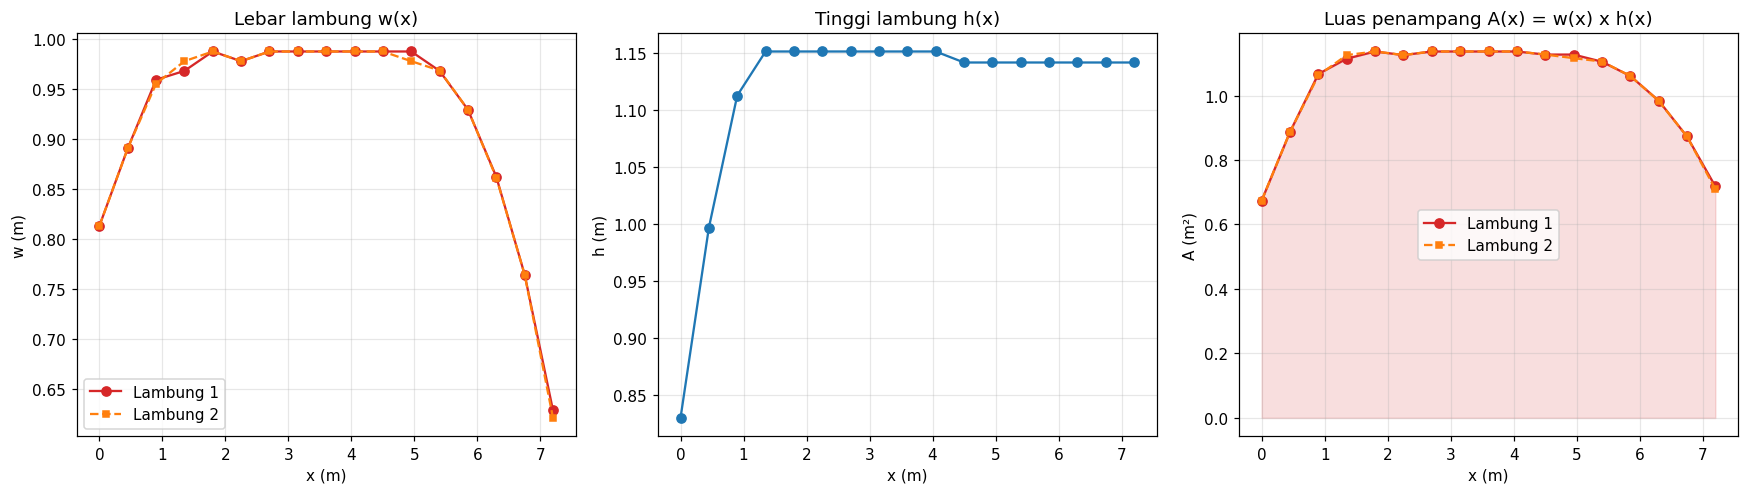

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

ax[0].plot(x, w1, "o-", color="tab:red", label="Lambung 1")
ax[0].plot(x, w2, "s--", color="tab:orange", label="Lambung 2", ms=4)
ax[0].set_title("Lebar lambung w(x)")
ax[0].set_xlabel("x (m)")
ax[0].set_ylabel("w (m)")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(x, h, "o-", color="tab:blue")
ax[1].set_title("Tinggi lambung h(x)")
ax[1].set_xlabel("x (m)")
ax[1].set_ylabel("h (m)")
ax[1].grid(alpha=0.3)

ax[2].plot(x, A1, "o-", color="tab:red", label="Lambung 1")
ax[2].plot(x, A2, "s--", color="tab:orange", label="Lambung 2", ms=4)
ax[2].fill_between(x, A1, alpha=0.15, color="tab:red")
ax[2].set_title("Luas penampang A(x) = w(x) x h(x)")
ax[2].set_xlabel("x (m)")
ax[2].set_ylabel("A (m²)")
ax[2].legend()
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Penjelasan:** Grafik kiri menunjukkan lebar lambung $w(x)$ yang membesar dari ujung kiri, relatif konstan di bagian tengah, lalu mengecil lebih cepat ke ujung kanan. Grafik tengah menunjukkan tinggi $h(x)$ yang naik tajam pada bagian awal lalu datar. Grafik kanan menunjukkan luas penampang $A(x) = w(x) \times h(x)$ yang berbentuk lonceng dan hampir berimpit untuk kedua lambung.

Volume satu lambung adalah luas daerah di bawah kurva $A(x)$ (daerah yang diarsir), yaitu:

$$
V = \int_{x_0}^{x_{16}} A(x)\,dx
$$

Integral ini dihitung secara numerik dengan metode Trapesium dan Simpson 1/3 pada fase berikutnya.

## Fase 5: Integrasi Numerik (Trapesium dan Simpson 1/3)

**Tujuan fase ini:** menghitung volume lambung, yaitu luas daerah di bawah kurva $A(x)$ dari $x_0$ sampai $x_{16}$. Kurva $A(x)$ hanya kita ketahui pada 17 titik, sehingga integralnya tidak bisa dihitung secara eksak dan harus dihampiri dengan dua metode numerik. Langkah-langkahnya:

1. Menulis fungsi Trapesium dan Simpson 1/3 sendiri (memakai loop), lalu mengeceknya dengan fungsi library.
2. Menghitung volume lambung 1 dan lambung 2 secara terpisah, kemudian menjumlahkannya.
3. Memvisualisasikan bentuk hampiran kedua metode pada kurva $A(x)$.

**Arti simbol:**
- $A_i$ = luas penampang pada titik ke-$i$ (m²), nilainya dari Fase 4.
- $h$ = jarak antar titik berurutan = 0,45 m.
- $N$ = jumlah interval = 16, sedangkan jumlah titik = $N+1 = 17$.
- $V_T$ dan $V_S$ = volume hasil metode Trapesium dan metode Simpson 1/3 (m³).

**a) Menulis fungsi Trapesium dan Simpson 1/3 dari nol**

**Metode Trapesium.** Setiap interval $[x_i, x_{i+1}]$ dihampiri sebagai trapesium. Luasnya adalah rata-rata dua sisi sejajar ($A_i$ dan $A_{i+1}$) dikali lebar $h$. Titik ujung ($A_0$ dan $A_N$) hanya dipakai satu trapesium, sedangkan titik dalam dipakai dua trapesium sehingga dihitung dua kali:

$$
V_T = \frac{h}{2}\left[A_0 + 2\sum_{i=1}^{N-1} A_i + A_N\right]
$$

**Metode Simpson 1/3.** Setiap *dua* interval berurutan dihampiri satu parabola yang melalui tiga titik. Karena itu $N$ harus genap. Titik ganjil diberi bobot 4, titik genap di dalam diberi bobot 2, dan titik ujung diberi bobot 1:

$$
V_S = \frac{h}{3}\left[A_0 + 4\sum_{i\ \mathrm{ganjil}} A_i + 2\sum_{i\ \mathrm{genap},\ 0<i<N} A_i + A_N\right]
$$

Pada kode di bawah, `A` adalah larik yang berisi $A_0 \ldots A_N$ dan `h` adalah jarak antar titik.

In [13]:
def trapesium_manual(A, h):
    # A = larik luas penampang tiap titik (m^2), h = jarak antar titik (m)
    n = len(A) - 1                                      # jumlah interval N = jumlah titik - 1
    jumlah_tengah = 0.0                                 # penampung jumlah A_1 ... A_(N-1)
    for i in range(1, n):                               # ulangi untuk titik-titik di antara ujung
        jumlah_tengah += A[i]                           # tambahkan A_i ke penampung
    return h / 2 * (A[0] + 2 * jumlah_tengah + A[n])    # V_T = h/2 [A_0 + 2*jumlah tengah + A_N]


def simpson_manual(A, h):
    # A = larik luas penampang tiap titik (m^2), h = jarak antar titik (m)
    n = len(A) - 1                                      # jumlah interval N
    assert n % 2 == 0, "Simpson 1/3 butuh N genap"      # syarat Simpson 1/3: N harus genap
    jumlah_ganjil = 0.0                                 # penampung A_i dengan i ganjil
    jumlah_genap = 0.0                                  # penampung A_i dengan i genap (tanpa ujung)
    for i in range(1, n):                               # ulangi untuk titik-titik di antara ujung
        if i % 2 == 1:                                  # jika indeks ganjil
            jumlah_ganjil += A[i]                       # tambahkan ke penampung ganjil
        else:                                           # jika indeks genap
            jumlah_genap += A[i]                        # tambahkan ke penampung genap
    return h / 3 * (A[0] + 4 * jumlah_ganjil + 2 * jumlah_genap + A[n])  # V_S = h/3 [A_0 + 4*ganjil + 2*genap + A_N]

**Penjelasan:** Sel ini hanya mendefinisikan dua fungsi sehingga tidak menampilkan keluaran. Fungsi `trapesium_manual` menerapkan rumus $V_T$ dan fungsi `simpson_manual` menerapkan rumus $V_S$ secara langsung memakai perulangan. Pada fungsi Simpson terdapat pernyataan `assert n % 2 == 0` yang menghentikan program apabila jumlah interval ganjil, karena metode Simpson 1/3 hanya berlaku untuk jumlah interval genap. Dengan $N = 16$, syarat tersebut terpenuhi.

**b) Mengecek fungsi buatan sendiri dengan library**

Sebelum fungsi dipakai untuk hasil akhir, fungsi tersebut dibandingkan dengan fungsi bawaan `numpy` (trapesium) dan `scipy` (Simpson) pada data yang sama. Jika rumus sudah benar, selisihnya harus mendekati nol (hanya galat pembulatan komputer).

In [14]:
from scipy.integrate import simpson                     # Simpson dari library (untuk pengecekan)

trapezoid_lib = np.trapezoid if hasattr(np, "trapezoid") else np.trapz  # nama fungsi trapesium beda antar versi NumPy

# Hitung dengan fungsi buatan sendiri
VT1, VT2 = trapesium_manual(A1, h_langkah), trapesium_manual(A2, h_langkah)  # trapesium lambung 1 dan 2
VS1, VS2 = simpson_manual(A1, h_langkah), simpson_manual(A2, h_langkah)      # Simpson lambung 1 dan 2

# Hitung dengan library sebagai pembanding
VT1_lib, VT2_lib = trapezoid_lib(A1, x=x), trapezoid_lib(A2, x=x)            # trapesium library
VS1_lib, VS2_lib = simpson(A1, x=x), simpson(A2, x=x)                        # Simpson library

# Tabel pengecekan: buatan sendiri vs library
cek = pd.DataFrame({
    "Metode": ["Trapesium L1", "Trapesium L2", "Simpson 1/3 L1", "Simpson 1/3 L2"],   # nama baris
    "Buatan sendiri (m³)": [VT1, VT2, VS1, VS2],                                       # hasil fungsi manual
    "Library (m³)": [VT1_lib, VT2_lib, VS1_lib, VS2_lib],                              # hasil library
})
cek["Selisih mutlak"] = (cek["Buatan sendiri (m³)"] - cek["Library (m³)"]).abs()       # selisih keduanya
print(cek.to_string(index=False, float_format=lambda v: f"{v:.10f}"))                  # tampilkan 10 desimal

        Metode  Buatan sendiri (m³)  Library (m³)  Selisih mutlak
  Trapesium L1         7.5840463540  7.5840463540    0.0000000000
  Trapesium L2         7.5799480419  7.5799480419    0.0000000000
Simpson 1/3 L1         7.5948007003  7.5948007003    0.0000000000
Simpson 1/3 L2         7.5920965893  7.5920965893    0.0000000000


**Penjelasan:** Tabel membandingkan hasil fungsi buatan sendiri dengan fungsi bawaan `numpy` (Trapesium) dan `scipy` (Simpson) pada data yang sama. Selisih mutlak bernilai $0{,}0000000000$ pada keempat baris, atau identik hingga sepuluh angka desimal. Hasil ini menunjukkan bahwa rumus Trapesium dan Simpson 1/3 telah diimplementasikan dengan benar, sehingga fungsi buatan sendiri dapat dipakai pada perhitungan selanjutnya. Pengecekan ini hanya memvalidasi implementasi rumus. Pengaruh jumlah titik penampang terhadap hasil diperiksa pada Fase 6 (uji konvergensi).

**c) Volume kedua lambung**

Volume lambung 1 dan lambung 2 dihitung secara terpisah, lalu dijumlahkan menjadi volume kedua lambung:

$$
V_{\text{total}} = V_1 + V_2
$$

Hasilnya dibandingkan dengan $2 \times V_1$ (anggapan bahwa kedua lambung identik) untuk melihat seberapa besar perbedaannya. Satuan diubah dari m³ ke liter dengan $1\ \text{m}^3 = 1000$ liter.

In [15]:
V_T_total = VT1 + VT2                                   # volume kedua lambung (trapesium)
V_S_total = VS1 + VS2                                   # volume kedua lambung (Simpson)

hasil5 = pd.DataFrame({
    "Bagian": ["Lambung 1", "Lambung 2", "Kedua lambung (V1 + V2)", "2 x Lambung 1"],  # baris tabel
    "Trapesium (m³)": [VT1, VT2, V_T_total, 2 * VT1],                                   # kolom trapesium
    "Simpson 1/3 (m³)": [VS1, VS2, V_S_total, 2 * VS1],                                 # kolom Simpson
})
hasil5["Trapesium (liter)"] = hasil5["Trapesium (m³)"] * 1000                           # 1 m^3 = 1000 liter
hasil5["Simpson 1/3 (liter)"] = hasil5["Simpson 1/3 (m³)"] * 1000                       # 1 m^3 = 1000 liter
print(hasil5.round(4).to_string(index=False))                                           # tampilkan tabel

selisih_dua = abs(V_S_total - 2 * VS1) / V_S_total * 100                                # selisih relatif V1+V2 vs 2xV1
print(f"\nSelisih (V1 + V2) terhadap (2 x V1), Simpson : {selisih_dua:.3f} %")
print(f"Selisih Trapesium vs Simpson (kedua lambung)  : {abs(V_T_total - V_S_total):.5f} m³ "
      f"({abs(V_T_total - V_S_total) / V_S_total * 100:.3f} %)")

                 Bagian  Trapesium (m³)  Simpson 1/3 (m³)  Trapesium (liter)  Simpson 1/3 (liter)
              Lambung 1          7.5840            7.5948          7584.0464            7594.8007
              Lambung 2          7.5799            7.5921          7579.9480            7592.0966
Kedua lambung (V1 + V2)         15.1640           15.1869         15163.9944           15186.8973
          2 x Lambung 1         15.1681           15.1896         15168.0927           15189.6014

Selisih (V1 + V2) terhadap (2 x V1), Simpson : 0.018 %
Selisih Trapesium vs Simpson (kedua lambung)  : 0.02290 m³ (0.151 %)


**Penjelasan:** Volume lambung 1 adalah $7{,}5948\ \text{m}^3$ dan lambung 2 adalah $7{,}5921\ \text{m}^3$ (metode Simpson 1/3). Volume kedua lambung adalah jumlah keduanya:

$$
V_{\text{total}} = V_1 + V_2 = 7{,}5948 + 7{,}5921 = 15{,}1869\ \text{m}^3 \approx 15.187\ \text{liter}
$$

Metode Trapesium memberikan $15{,}1640\ \text{m}^3$ (sekitar 15.164 liter). Selisih kedua metode adalah $0{,}0229\ \text{m}^3$ atau $0{,}151\%$, sehingga kedua metode menghasilkan nilai yang sangat dekat.

Volume lambung 1 dan lambung 2 hanya berbeda $0{,}0027\ \text{m}^3$ (sekitar $0{,}04\%$). Jika volume kedua lambung dihitung sebagai $2 \times V_1 = 15{,}1896\ \text{m}^3$, selisihnya terhadap $V_1 + V_2$ hanya $0{,}018\%$. Hal ini mendukung anggapan bahwa kedua lambung berbentuk identik, dan perbedaan kecil yang ada berasal dari pembulatan pembacaan gambar sebesar kurang lebih satu piksel.

Metode Trapesium menghasilkan nilai sedikit lebih kecil daripada Simpson. Hal ini wajar karena kurva $A(x)$ melengkung, sedangkan ruas garis lurus pada metode Trapesium cenderung berada di bawah kurva yang melengkung ke atas. Penjelasan visualnya diberikan pada grafik berikut.

**d) Visualisasi bentuk hampiran kedua metode**

Grafik ini memperlihatkan apa yang sebenarnya "dihitung" oleh kedua metode. Bagian yang diperbesar adalah $x_0$ sampai $x_8$ pada lambung 1, yaitu bagian tempat kurva $A(x)$ paling banyak berubah. Garis hitam adalah kurva $A(x)$ yang dibaca langsung dari gambar (sebagai acuan), dan titik merah adalah 17 titik penampang. Panel kiri memperlihatkan hampiran garis lurus (trapesium), dan panel kanan memperlihatkan hampiran parabola per dua interval (Simpson). Luas daerah berwarna pada tiap panel adalah volume hasil metode tersebut.

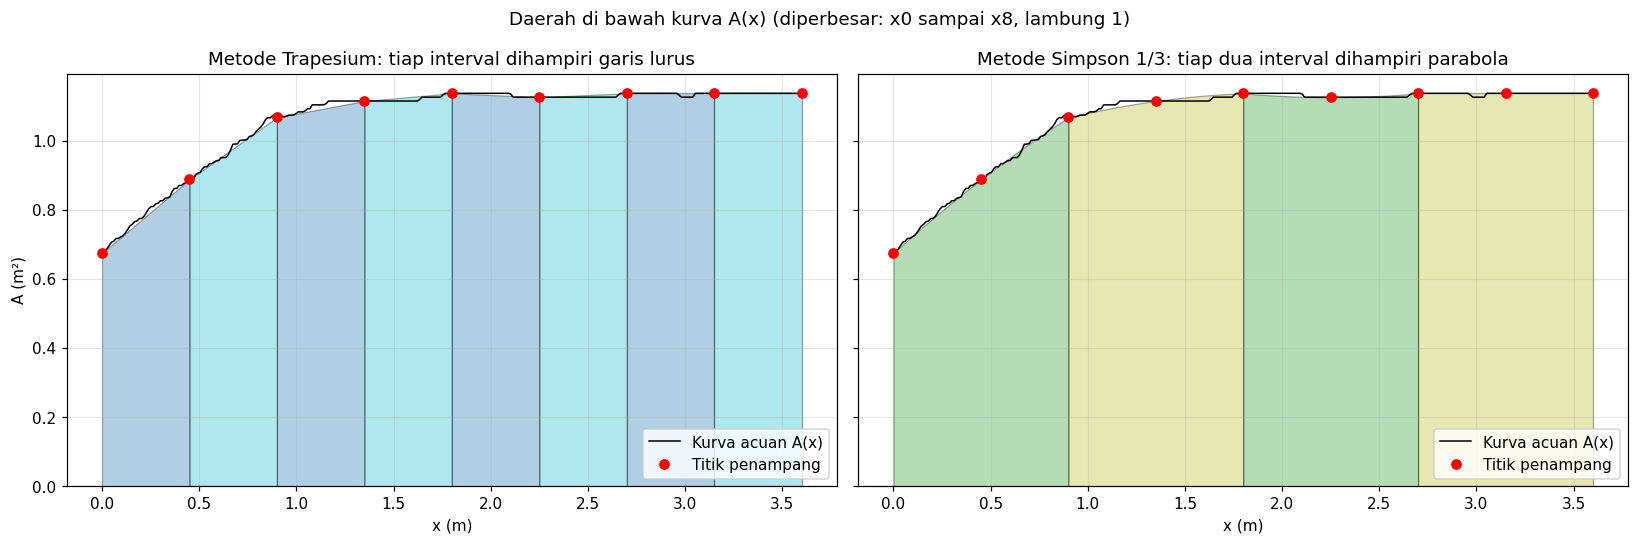

In [16]:
def A_halus(px, atas, bawah):
    # Luas penampang kontinu A(x) dari kurva tepi hasil deteksi (dipakai sebagai kurva acuan)
    w = (np.interp(px, kolom, bawah) - np.interp(px, kolom, atas) + 1) * CM_PER_PX_Y / 100   # lebar (m)
    t = (np.interp(px, kolom, dasar) - Y_SHEER + 1) * CM_PER_PX_Y / 100                      # tinggi (m)
    return w * t                                                                             # luas = lebar x tinggi


px_halus = np.linspace(stasiun_px[0], stasiun_px[-1], 600)       # 600 posisi rapat sepanjang daerah hitung
x_halus = (px_halus - stasiun_px[0]) * CM_PER_PX_X / 100         # posisi tersebut dalam meter
A_acuan = A_halus(px_halus, atas1, bawah1)                       # kurva acuan A(x) lambung 1

K = 8                                                            # zoom: titik x0 ... x8 (8 interval, genap)
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)       # dua panel berdampingan

# Panel kiri: trapesium (potongan lurus antar titik)
for i in range(K):                                               # satu trapesium per interval
    ax[0].fill_between(x[i:i + 2], A1[i:i + 2], alpha=0.35,      # isi area di bawah ruas garis lurus
                       color="tab:blue" if i % 2 == 0 else "tab:cyan", edgecolor="k", lw=0.8)  # warna selang-seling
ax[0].plot(x_halus[x_halus <= x[K]], A_acuan[x_halus <= x[K]], "k-", lw=1, label="Kurva acuan A(x)")  # kurva acuan
ax[0].plot(x[:K + 1], A1[:K + 1], "ro", label="Titik penampang")  # titik data
ax[0].set_title("Metode Trapesium: tiap interval dihampiri garis lurus")  # judul panel

# Panel kanan: Simpson (parabola melalui tiga titik berturut-turut)
for k in range(0, K, 2):                                         # satu parabola per pasangan interval
    xx, AA = x[k:k + 3], A1[k:k + 3]                             # tiga titik: x_k, x_(k+1), x_(k+2)
    koef = np.polyfit(xx, AA, 2)                                 # parabola melalui 3 titik tersebut
    xp = np.linspace(xx[0], xx[-1], 80)                          # posisi rapat untuk menggambar parabola
    ax[1].fill_between(xp, np.polyval(koef, xp), alpha=0.35,     # isi area di bawah parabola
                       color="tab:green" if (k // 2) % 2 == 0 else "tab:olive", edgecolor="k", lw=0.8)  # warna selang-seling
ax[1].plot(x_halus[x_halus <= x[K]], A_acuan[x_halus <= x[K]], "k-", lw=1, label="Kurva acuan A(x)")  # kurva acuan
ax[1].plot(x[:K + 1], A1[:K + 1], "ro", label="Titik penampang")  # titik data
ax[1].set_title("Metode Simpson 1/3: tiap dua interval dihampiri parabola")  # judul panel

for a in ax:                                                     # pengaturan yang sama untuk kedua panel
    a.set_xlabel("x (m)")                                        # label sumbu x
    a.set_ylim(0, None)                                          # mulai dari nol
    a.grid(alpha=0.3)                                            # grid tipis
    a.legend(loc="lower right")                                  # legenda
ax[0].set_ylabel("A (m²)")                                       # label sumbu y
plt.suptitle("Daerah di bawah kurva A(x) (diperbesar: x0 sampai x8, lambung 1)")  # judul utama
plt.tight_layout()                                               # rapikan tata letak
plt.show()                                                       # tampilkan grafik

**Penjelasan:** Grafik memperlihatkan bagian $x_0$ sampai $x_8$ lambung 1. Garis hitam adalah kurva $A(x)$ yang dibaca dari gambar, dan titik merah adalah titik penampang. Undak-undak kecil pada garis hitam muncul karena gambar dibaca per piksel, bukan karena kesalahan perhitungan.

Luas penampang naik tajam dari sekitar $0,67\ \text{m}^2$ pada $x_0$ menjadi sekitar $1,11\ \text{m}^2$ pada $x_3$, lalu hampir konstan di sekitar $1,13$ sampai $1,14\ \text{m}^2$. Pada panel kiri (Trapesium), setiap interval dihampiri satu ruas garis lurus. Pada bagian yang naik tajam ($x_0$ sampai $x_3$), ruas tersebut berada sedikit di bawah kurva karena kurva melengkung. Pada panel kanan (Simpson 1/3), setiap dua interval dihampiri satu parabola yang melalui tiga titik, sehingga lengkungan kurva diikuti lebih baik. Pada bagian datar ($x_4$ sampai $x_8$), kedua metode hampir tidak berbeda. Gambaran ini sejalan dengan hasil sebelumnya, yaitu Trapesium sedikit lebih kecil daripada Simpson, dengan selisih total yang kecil ($0{,}151\%$).

## Fase 6: Uji Konvergensi

**Tujuan fase ini:** memastikan hasil Fase 5 dapat dipercaya dan tidak bergantung pada pemilihan jumlah titik. Perhitungan diulang dengan jumlah interval $N = 8, 16, 32, 64, 128$. Jika metode benar, makin besar $N$ hasilnya makin mendekati satu nilai tertentu.

**Arti simbol:**
- $N$ = jumlah interval, dan $h = L/N$ = jarak antar titik, dengan $L = 7{,}2$ m panjang daerah hitung.
- Galat relatif terhadap nilai acuan $V_{\text{acuan}}$:

$$
\text{galat relatif} = \frac{|V - V_{\text{acuan}}|}{V_{\text{acuan}}} \times 100\%
$$

**a) Fungsi umum untuk menghitung volume dengan jumlah interval yang bisa diubah**

Pada Fase 5, titik penampang tetap pada 17 garis grid. Untuk menguji $N$ lain, titik penampang harus ditentukan ulang. Fungsi `hitung_volume` di bawah membaca ulang $w(x)$ dan $h(x)$ dari kurva tepi hasil deteksi (Fase 3) pada $N+1$ titik berjarak sama di antara dua sekat, lalu memanggil fungsi integrasi buatan sendiri dari Fase 5. Pada $N=16$ hasilnya harus hampir sama dengan Fase 5. Selisih kecil bisa muncul karena Fase 5 memakai titik pada garis grid yang jaraknya tidak persis sama, sedangkan fungsi ini memakai jarak yang persis sama.

In [17]:
def hitung_volume(n_int, metode, atas, bawah, px_kiri=None, px_kanan=None, cm_per_kotak=CM_PER_KOTAK):
    # Volume satu lambung untuk jumlah interval, metode, batas, dan skala tertentu
    px_kiri = stasiun_px[0] if px_kiri is None else px_kiri          # batas kiri default = sekat kiri
    px_kanan = stasiun_px[-1] if px_kanan is None else px_kanan      # batas kanan default = sekat kanan
    cm_px_x = cm_per_kotak / kotak_p_x                               # skala sumbu x (cm/piksel) untuk skala ini
    cm_px_y = cm_per_kotak / kotak_p_y                               # skala sumbu y (cm/piksel) untuk skala ini
    px = np.linspace(px_kiri, px_kanan, n_int + 1)                   # titik penampang berjarak sama
    w = (np.interp(px, kolom, bawah) - np.interp(px, kolom, atas) + 1) * cm_px_y / 100   # lebar (m)
    t = (np.interp(px, kolom, dasar) - Y_SHEER + 1) * cm_px_y / 100                      # tinggi (m)
    A = w * t                                                        # luas penampang (m^2)
    langkah = (px_kanan - px_kiri) / n_int * cm_px_x / 100           # jarak antar titik (m)
    if metode == "trapesium":                                        # pilih metode trapesium
        return trapesium_manual(A, langkah)                          # hitung trapesium
    return simpson_manual(A, langkah)                                # selain itu Simpson 1/3


# Pengecekan: pada N = 16 hasilnya harus (hampir) sama dengan Fase 5
V_cek = hitung_volume(16, "simpson", atas1, bawah1)                  # Simpson N = 16 dari fungsi baru
print(f"Simpson N=16 fungsi baru : {V_cek:.5f} m³")
print(f"Simpson N=16 Fase 5      : {VS1:.5f} m³  (selisih {abs(V_cek - VS1) / VS1 * 100:.3f} %)")

Simpson N=16 fungsi baru : 7.59353 m³
Simpson N=16 Fase 5      : 7.59480 m³  (selisih 0.017 %)


**Penjelasan:** Fungsi `hitung_volume` pada $N = 16$ menghasilkan $7{,}59353\ \text{m}^3$, sedangkan Fase 5 menghasilkan $7{,}59480\ \text{m}^3$ (selisih $0{,}017\%$). Kedua nilai tidak identik karena titik penampang pada Fase 5 berada pada garis grid yang jaraknya tidak persis sama (hasil pembulatan posisi piksel), sedangkan fungsi ini memakai titik dengan jarak yang persis sama. Selisih sekecil $0{,}017\%$ menunjukkan bahwa fungsi baru konsisten dengan Fase 5, sehingga layak dipakai untuk uji konvergensi.

**b) Uji konvergensi terhadap jumlah interval $N$**

Volume lambung 1 dihitung dengan $N = 8, 16, 32, 64, 128$ untuk kedua metode. Sebagai nilai acuan dipakai Simpson dengan $N = 4096$, yaitu jauh lebih halus daripada semua $N$ yang diuji, sehingga tidak ada metode yang "menilai dirinya sendiri". Galat relatif tiap hasil dihitung terhadap acuan tersebut.

In [18]:
daftar_N = [8, 16, 32, 64, 128]                                      # jumlah interval yang diuji
baris = []                                                           # penampung hasil tiap N
for n_int in daftar_N:                                               # ulangi untuk tiap N
    vt = hitung_volume(n_int, "trapesium", atas1, bawah1)            # volume trapesium
    vs = hitung_volume(n_int, "simpson", atas1, bawah1)              # volume Simpson
    baris.append({"N": n_int, "h (m)": N * h_langkah / n_int, "V Trapesium (m³)": vt, "V Simpson (m³)": vs})  # simpan baris
konv = pd.DataFrame(baris)                                           # ubah ke tabel

N_ACUAN = 4096                                                       # N sangat halus sebagai acuan (jauh di atas N yang diuji)
V_ref = hitung_volume(N_ACUAN, "simpson", atas1, bawah1)             # acuan = Simpson dengan N = 4096
konv["Galat Trapesium (%)"] = (konv["V Trapesium (m³)"] - V_ref).abs() / V_ref * 100   # galat relatif trapesium
konv["Galat Simpson (%)"] = (konv["V Simpson (m³)"] - V_ref).abs() / V_ref * 100       # galat relatif Simpson
print(f"Volume acuan (Simpson, N = {N_ACUAN}) lambung 1 = {V_ref:.5f} m³\n")
print(konv.round(5).to_string(index=False))                          # tampilkan tabel konvergensi

Volume acuan (Simpson, N = 4096) lambung 1 = 7.58472 m³

  N   h (m)  V Trapesium (m³)  V Simpson (m³)  Galat Trapesium (%)  Galat Simpson (%)
  8 0.90000           7.54994         7.62181              0.45855            0.48898
 16 0.45000           7.58263         7.59353              0.02757            0.11609
 32 0.22500           7.58773         7.58943              0.03962            0.06202
 64 0.11250           7.58269         7.58101              0.02678            0.04891
128 0.05625           7.58350         7.58377              0.01613            0.01258


**Penjelasan:** Tabel memuat volume lambung 1 untuk lima nilai $N$. Nilai acuan adalah hasil Simpson dengan $N = 4096$, yaitu $7{,}58472\ \text{m}^3$, yang jauh lebih halus daripada semua $N$ yang diuji. Galat relatif dihitung dengan:

$$
\text{galat relatif} = \frac{|V - V_{\text{acuan}}|}{V_{\text{acuan}}} \times 100\%
$$

Hasilnya sebagai berikut.
- Pada $N = 8$ (jarak antar titik $0,900$ m), galat masih sekitar $0{,}46\%$ (Trapesium) dan $0{,}49\%$ (Simpson), karena titik terlalu jarang untuk menangkap perubahan $A(x)$ yang tajam di dekat ujung kiri.
- Mulai $N = 16$ galat kedua metode turun menjadi paling besar $0{,}12\%$.
- Pada $N = 128$ galat hanya $0{,}016\%$ (Trapesium) dan $0{,}013\%$ (Simpson).
- Seluruh nilai volume berada pada rentang sekitar $7{,}55$ sampai $7{,}62\ \text{m}^3$ dan mengerucut ke sekitar $7{,}58\ \text{m}^3$.

Galat Simpson menurun secara konsisten seiring bertambahnya $N$. Galat Trapesium turun lebih tidak teratur, yaitu naik sedikit dari $N = 16$ ke $N = 32$. Secara teori Simpson konvergen lebih cepat untuk fungsi yang mulus, tetapi di sini data berasal dari piksel gambar yang bernilai bulat, sehingga kurvanya tidak mulus sempurna dan keunggulan tersebut tidak tampak jelas. Untuk $N \geq 16$ pun kedua metode sudah berada dalam $0{,}12\%$ dari acuan, sehingga pilihan $N = 16$ pada Fase 5 sudah memadai.

**c) Visualisasi konvergensi**

Panel kiri menampilkan volume terhadap $N$ (sumbu $N$ berskala log basis 2), dan garis putus-putus abu-abu adalah nilai acuan. Panel kanan menampilkan galat relatif terhadap $N$ pada skala log. Jika kedua metode benar, kurva pada panel kiri mendekati garis acuan dan kurva pada panel kanan menurun saat $N$ membesar.

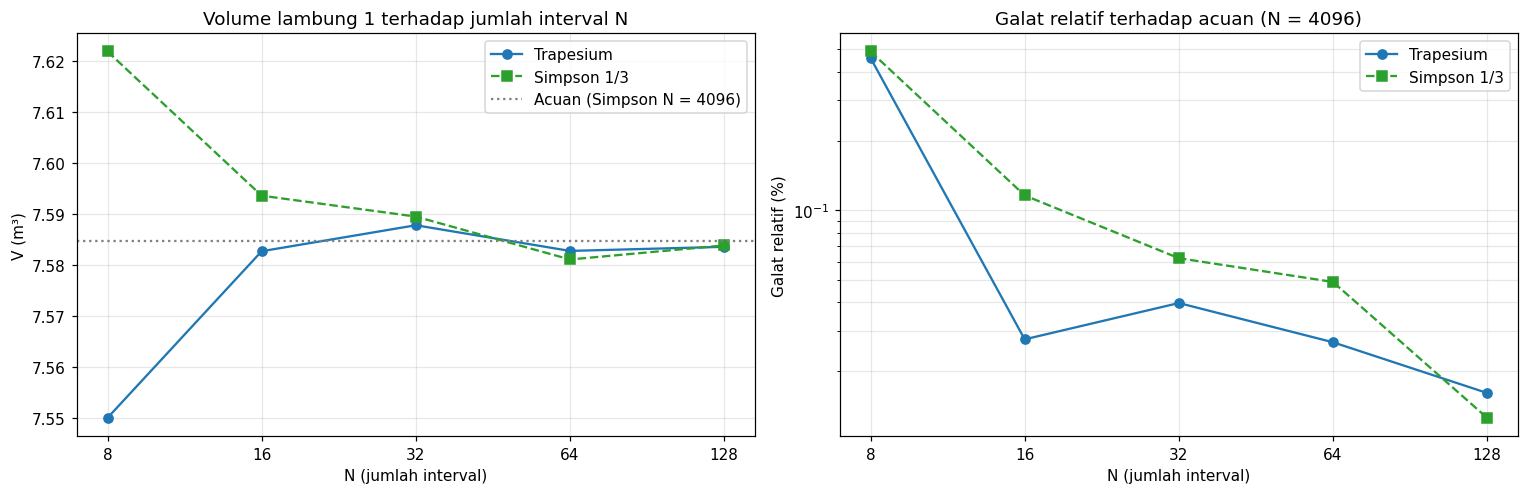

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))                      # dua panel berdampingan

ax[0].plot(konv["N"], konv["V Trapesium (m³)"], "o-", color="tab:blue", label="Trapesium")   # kurva trapesium
ax[0].plot(konv["N"], konv["V Simpson (m³)"], "s--", color="tab:green", label="Simpson 1/3") # kurva Simpson
ax[0].axhline(V_ref, color="gray", ls=":", label=f"Acuan (Simpson N = {N_ACUAN})")           # garis acuan
ax[0].set_xscale("log", base=2)                                      # sumbu x skala log basis 2
ax[0].set_xticks(daftar_N)                                           # tampilkan nilai N yang diuji
ax[0].set_xticklabels(daftar_N)                                      # label tick berupa angka N
ax[0].set_title("Volume lambung 1 terhadap jumlah interval N")       # judul panel kiri
ax[0].set_xlabel("N (jumlah interval)")                              # label sumbu x
ax[0].set_ylabel("V (m³)")                                           # label sumbu y
ax[0].legend()                                                       # legenda
ax[0].grid(alpha=0.3)                                                # grid tipis

g_t = konv["Galat Trapesium (%)"].clip(lower=1e-8)                   # hindari nol agar bisa digambar di skala log
g_s = konv["Galat Simpson (%)"].clip(lower=1e-8)                     # hindari nol agar bisa digambar di skala log
ax[1].plot(konv["N"], g_t, "o-", color="tab:blue", label="Trapesium")    # galat trapesium
ax[1].plot(konv["N"], g_s, "s--", color="tab:green", label="Simpson 1/3")  # galat Simpson
ax[1].set_xscale("log", base=2)                                      # sumbu x skala log basis 2
ax[1].set_yscale("log")                                              # sumbu y skala log
ax[1].set_xticks(daftar_N)                                           # tampilkan nilai N yang diuji
ax[1].set_xticklabels(daftar_N)                                      # label tick berupa angka N
ax[1].set_title(f"Galat relatif terhadap acuan (N = {N_ACUAN})")     # judul panel kanan
ax[1].set_xlabel("N (jumlah interval)")                              # label sumbu x
ax[1].set_ylabel("Galat relatif (%)")                                # label sumbu y
ax[1].legend()                                                       # legenda
ax[1].grid(alpha=0.3, which="both")                                  # grid tipis

plt.tight_layout()                                                   # rapikan tata letak
plt.show()                                                           # tampilkan grafik

**Penjelasan:** Panel kiri memperlihatkan volume terhadap $N$. Pada $N = 8$ hasil Trapesium berada di bawah garis acuan (sekitar $7{,}55\ \text{m}^3$) dan hasil Simpson berada di atasnya (sekitar $7{,}62\ \text{m}^3$). Saat $N$ membesar, kedua kurva mendekati garis acuan dan pada $N = 128$ keduanya hampir berimpit dengannya. Panel kanan memperlihatkan galat relatif pada skala logaritmik. Kedua kurva secara keseluruhan menurun dari sekitar $0{,}5\%$ pada $N = 8$ menjadi sekitar $0{,}01\%$ sampai $0{,}02\%$ pada $N = 128$. Kedua grafik menegaskan bahwa hasil kedua metode stabil dan mengarah ke satu nilai yang sama, sehingga hasil perhitungan tidak bergantung pada pemilihan jumlah titik.

## Fase 7: Hasil Akhir

**Tujuan fase ini:** merangkum seluruh hasil menjadi jawaban akhir tugas, yaitu volume kedua lambung.

**a) Tabel hasil akhir**

Tabel memuat volume tiap lambung dan volume kedua lambung dari kedua metode. Selisih kedua metode dihitung sebagai selisih mutlak dan persentase terhadap hasil Simpson:

$$
\text{selisih (\%)} = \frac{|V_T - V_S|}{V_S} \times 100\%
$$

In [20]:
V_total_T, V_total_S = VT1 + VT2, VS1 + VS2                  # volume kedua lambung dari Fase 5
selisih_abs = abs(V_total_T - V_total_S)                     # selisih mutlak kedua metode (m^3)
selisih_pct = selisih_abs / V_total_S * 100                  # selisih relatif terhadap Simpson (%)

tabel_akhir = pd.DataFrame({
    "Metode": ["Trapesium", "Simpson 1/3"],                  # dua metode integrasi
    "V lambung 1 (m³)": [VT1, VS1],                          # volume lambung 1
    "V lambung 2 (m³)": [VT2, VS2],                          # volume lambung 2
    "V kedua lambung (m³)": [V_total_T, V_total_S],          # volume kedua lambung
    "V kedua lambung (liter)": [V_total_T * 1000, V_total_S * 1000],  # dalam liter
})
print(tabel_akhir.round(4).to_string(index=False))           # tampilkan tabel akhir
print(f"\nSelisih kedua metode : {selisih_abs:.4f} m³ = {selisih_abs * 1000:.1f} liter ({selisih_pct:.3f} %)")

     Metode  V lambung 1 (m³)  V lambung 2 (m³)  V kedua lambung (m³)  V kedua lambung (liter)
  Trapesium            7.5840            7.5799               15.1640               15163.9944
Simpson 1/3            7.5948            7.5921               15.1869               15186.8973

Selisih kedua metode : 0.0229 m³ = 22.9 liter (0.151 %)


**Penjelasan:** Tabel merangkum volume akhir dari kedua metode. Dengan metode Simpson 1/3, volume kedua lambung adalah $15{,}1869\ \text{m}^3$ atau 15.187 liter. Dengan metode Trapesium, volume kedua lambung adalah $15{,}1640\ \text{m}^3$ atau 15.164 liter. Selisih antar metode adalah $0{,}0229\ \text{m}^3$ ($22{,}9$ liter), atau $0{,}151\%$ terhadap hasil Simpson. Nilai yang dilaporkan sebagai hasil utama adalah hasil Simpson 1/3 karena metode ini secara teori memiliki orde galat yang lebih tinggi. Hasil Trapesium dipakai sebagai pembanding, dan kedua metode saling mendukung.

## Jawaban Soal

Soal meminta kita menghitung **volume kedua lambung** perahu katamaran dari gambar bergrid, dengan beberapa ketentuan. Tabel berikut menunjukkan bagaimana setiap ketentuan dijawab di notebook ini.

| No | Yang diminta soal | Cara menjawabnya | Hasil |
|----|-------------------|------------------|-------|
| 1 | **Satu dash-kosong = 5 + 5 cm** (dipakai untuk menentukan skala gambar) | Fase 1: satu dash dan satu celah bernilai 10 cm. Berdasarkan kesepakatan dengan dosen, ukuran satu kotak grid ditetapkan 45 cm (setara 4,5 pasang dash-celah). | **1 kotak grid = 45 cm** |
| 2 | **Lantai kapal datar (tanpa keel), sehingga tampak depan berbentuk persegi panjang** | Fase 3 dan 4: pada setiap titik, luas penampang dihitung sebagai lebar × tinggi, yaitu $A = w \times h$. Lebar dibaca dari tampak atas dan tinggi dibaca dari tampak samping. | Luas penampang berkisar dari sekitar 0,67 m² (ujung kiri) sampai sekitar 1,14 m² (bagian tengah) |
| 3 | **Volume *reserve buoyancy* tidak dihitung** | Fase 2: sekat *reserve buoyancy* di kiri dan kanan dideteksi otomatis, lalu perhitungan hanya dilakukan di antara kedua sekat. | Daerah yang dihitung sepanjang 7,2 m, yaitu di antara kedua sekat. Bagian ujung di luar sekat tidak dihitung. |
| 4 | **Hitung volume kedua lambung** (dengan metode Simpson dan Trapesium) | Fase 5: luas penampang diintegralkan sepanjang lambung dengan dua metode numerik. Lambung 1 dan lambung 2 dihitung sendiri-sendiri, lalu dijumlahkan. | **Volume kedua lambung ≈ 15,1869 m³ ≈ 15.187 liter** (Simpson 1/3) |

### Jawaban akhir

| Bagian | Volume (Simpson 1/3) | Volume (Trapesium) |
|--------|----------------------|--------------------|
| Lambung 1 | 7,5948 m³ (7.595 liter) | 7,5840 m³ (7.584 liter) |
| Lambung 2 | 7,5921 m³ (7.592 liter) | 7,5799 m³ (7.580 liter) |
| **Kedua lambung** | **15,1869 m³ (15.187 liter)** | **15,1640 m³ (15.164 liter)** |

**Jadi, volume kedua lambung perahu pada daerah di antara kedua sekat *reserve buoyancy* adalah sekitar 15,19 m³, atau sekitar 15.187 liter.** Kedua metode hanya berselisih 0,15%, sehingga angka ini dapat dipegang sebagai jawaban.

## Kesimpulan

**1. Cara menghitung.** Volume benda yang bentuknya berubah sepanjang panjangnya dapat dihitung dengan mengiris benda menjadi potongan melintang, menghitung luas tiap irisan, lalu menjumlahkannya sepanjang benda. Pada tugas ini skala gambar ditetapkan 1 kotak grid = 45 cm sesuai kesepakatan dengan dosen. Perhitungan dibatasi di antara kedua sekat *reserve buoyancy* sepanjang 7,2 m, lalu lambung diiris menjadi 17 penampang pada garis grid vertikal dengan jarak 0,45 m (16 interval, genap sehingga memenuhi syarat Simpson 1/3). Karena lantai kapal dianggap datar, setiap penampang berbentuk persegi panjang dengan luas $A = w \times h$. Lebar $w$ dibaca dari tampak atas dan tinggi $h$ dibaca dari tampak samping secara otomatis oleh program. Volume satu lambung adalah $V = \int A(x)\,dx$ yang dihitung dengan metode Trapesium dan Simpson 1/3, kemudian volume lambung 1 dan lambung 2 dijumlahkan.

**2. Hasil.** Volume kedua lambung adalah **15,1869 m³ (15.187 liter)** dengan metode Simpson 1/3 dan 15,1640 m³ (15.164 liter) dengan metode Trapesium. Selisih kedua metode hanya 0,15%, sehingga hasil Simpson 1/3 dilaporkan sebagai jawaban utama dan hasil Trapesium sebagai pembanding.

**3. Ketelitian.** Hasil dinilai dapat dipercaya karena tiga hal. Pertama, fungsi Trapesium dan Simpson buatan sendiri identik dengan fungsi `numpy` dan `scipy` pada data yang sama. Kedua, uji konvergensi menunjukkan bahwa untuk $N \geq 16$ galat kedua metode paling besar 0,12% terhadap nilai acuan, sehingga pemilihan $N = 16$ sudah memadai. Ketiga, volume lambung 1 dan lambung 2 hampir sama, yang mendukung anggapan bahwa kedua lambung berbentuk identik.

**4. Catatan.** Lebar dan tinggi dibaca per piksel sehingga ketelitiannya sekitar satu piksel (kurang lebih 1 cm pada skala ini). Selain itu, volume sebanding dengan pangkat tiga skala ($V \propto s^3$), sehingga hasil akhir sangat bergantung pada skala yang ditetapkan, yaitu 45 cm per kotak. Terakhir, tinggi lambung tidak konstan karena dasar lambung naik di dekat ujung kiri, sehingga tinggi dibaca pada setiap titik dan tidak diasumsikan tetap.